## Importa as bibliotecas:

In [1]:
import matplotlib.pyplot as plt
import pandas as pd 
import pingouin as pg
from sklearn.datasets import load_iris


## Visualizar os dados do dataset Iris:

In [5]:
# criar celula
from sklearn.datasets import load_iris

# carrega o dataset 
iris = load_iris()

#visualiza dados
iris["data"], iris["target"]

(array([[5.1, 3.5, 1.4, 0.2],
        [4.9, 3. , 1.4, 0.2],
        [4.7, 3.2, 1.3, 0.2],
        [4.6, 3.1, 1.5, 0.2],
        [5. , 3.6, 1.4, 0.2],
        [5.4, 3.9, 1.7, 0.4],
        [4.6, 3.4, 1.4, 0.3],
        [5. , 3.4, 1.5, 0.2],
        [4.4, 2.9, 1.4, 0.2],
        [4.9, 3.1, 1.5, 0.1],
        [5.4, 3.7, 1.5, 0.2],
        [4.8, 3.4, 1.6, 0.2],
        [4.8, 3. , 1.4, 0.1],
        [4.3, 3. , 1.1, 0.1],
        [5.8, 4. , 1.2, 0.2],
        [5.7, 4.4, 1.5, 0.4],
        [5.4, 3.9, 1.3, 0.4],
        [5.1, 3.5, 1.4, 0.3],
        [5.7, 3.8, 1.7, 0.3],
        [5.1, 3.8, 1.5, 0.3],
        [5.4, 3.4, 1.7, 0.2],
        [5.1, 3.7, 1.5, 0.4],
        [4.6, 3.6, 1. , 0.2],
        [5.1, 3.3, 1.7, 0.5],
        [4.8, 3.4, 1.9, 0.2],
        [5. , 3. , 1.6, 0.2],
        [5. , 3.4, 1.6, 0.4],
        [5.2, 3.5, 1.5, 0.2],
        [5.2, 3.4, 1.4, 0.2],
        [4.7, 3.2, 1.6, 0.2],
        [4.8, 3.1, 1.6, 0.2],
        [5.4, 3.4, 1.5, 0.4],
        [5.2, 4.1, 1.5, 0.1],
        [5

## Transformando dados em dataframe:

In [8]:
# carregar dataset
iris = load_iris()

# transformar em dataframe
df = pd.DataFrame(data=iris.data, columns=iris.feature_names)

# adicionar coluna de espécie
df['species'] = iris.target
df['species'] = df['species'].map({
    0: 'setosa',
    1: 'versicolor',
    2: 'virginica'
})

# mostrar primeiras linhas
print(df.head())

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

  species  
0  setosa  
1  setosa  
2  setosa  
3  setosa  
4  setosa  


## Questão 1 – estatística descritiva

In [ ]:
#escolhe a variavel desejada
variable = 'petal length (cm)'

# agrupa por especies e seleciona a variavel 
group = df.groupby('species')[variable]

# cria tabela com as estatisticas descritivas
tabela = pd.DataFrame({
    'N. Obs.': group.count(),
    'Media: ': group.mean(),
    'Desvio Padrão: ': group.std(),
    'Mediana: ': group.median(),
    'IQR: ': group.quantile(0.75) - group.quantile(0.25)
})

print(tabela)

            N. Obs.  Media:   Desvio Padrão:   Mediana:   IQR: 
species                                                        
setosa           50    1.462         0.173664       1.50  0.175
versicolor       50    4.260         0.469911       4.35  0.600
virginica        50    5.552         0.551895       5.55  0.775


## Questão 2 – histogramas

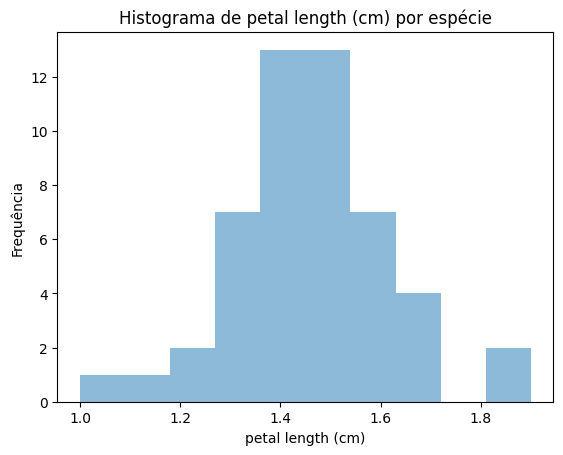

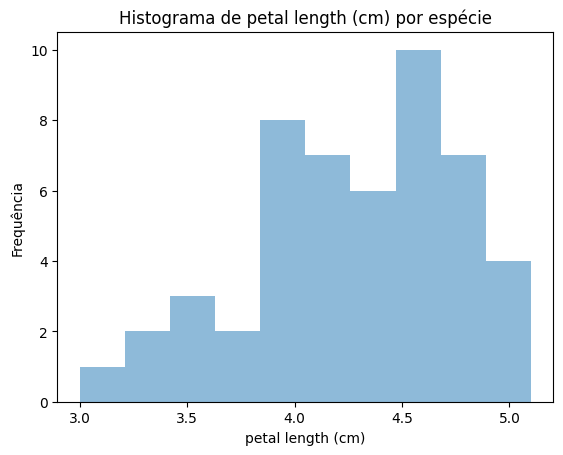

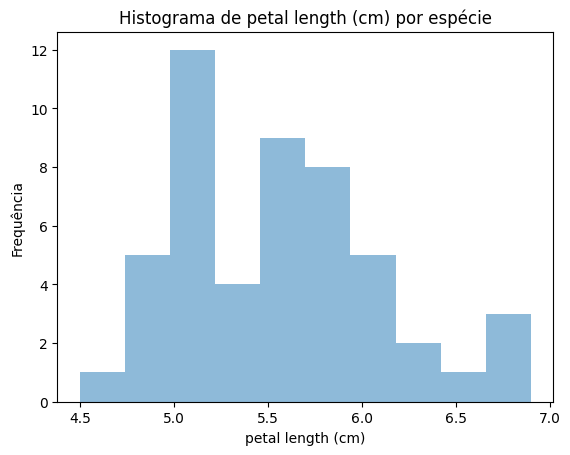

In [ ]:
variable = 'petal length (cm)'

# lista das especies
species_list = df['species'].unique()

# cria histograma de cada especie
for species in species_list:
    data = df[df['species'] == species][variable]

    # cria histograma
    plt.hist(data, alpha=0.5, label=species)

    # da um titulo 
    plt.title(f'Histograma de {variable} por espécie')

    plt.xlabel(variable) #eixo x

    plt.ylabel('Frequência') #eixo y

    # mostra o grafico
    plt.show()

## Questão 3 – Boxplot

/tmp/ipykernel_16359/3583342237.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=['Setosa', 'Versicolor', 'Virginica'])


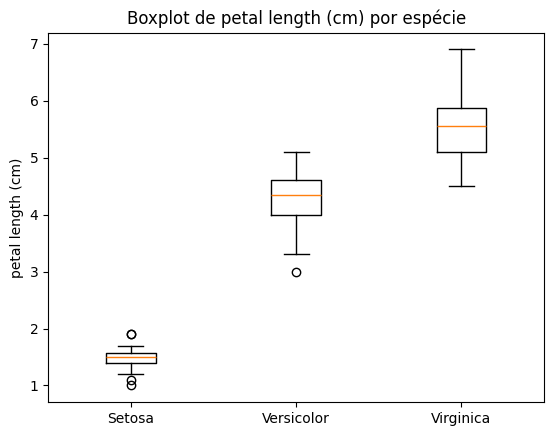

In [12]:
variable = 'petal length (cm)'

# cria uma lista com os dados de cada uma
data = [
    df[df['species'] == 'setosa'][variable],
    df[df['species'] == 'versicolor'][variable],
    df[df['species'] == 'virginica'][variable]
]

# cria o boxplot
plt.boxplot(data, labels=['Setosa', 'Versicolor', 'Virginica'])

# título do gráfico
plt.title(f'Boxplot de {variable} por espécie')

plt.ylabel(variable) # eixo y

# mostra o gráfico
plt.show()

## Questão 4 – Scatter Plot / grafico de dispersão

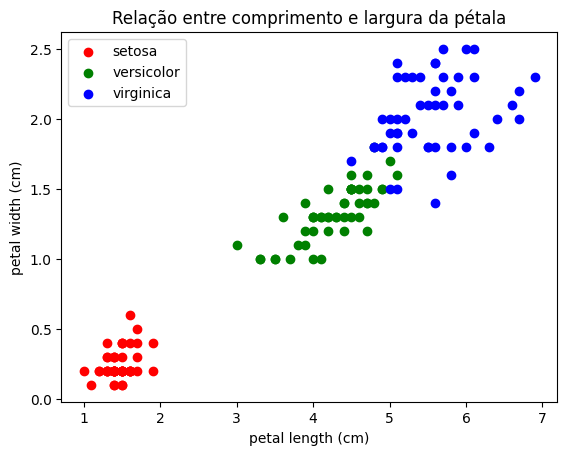

In [13]:
# variáveis escolhidas
x = 'petal length (cm)'
y = 'petal width (cm)'

# lista das especies
species_list = df['species'].unique()

# cores para cada uma
colors = ['red', 'green', 'blue']

# cria o grafico de dispersao 
for sp, color in zip(species_list, colors):
    
    # filtra os dados da espécie
    data = df[df['species'] == sp]
    
    # cria o grafico
    plt.scatter(data[x], data[y], label=sp, color=color)

# título do grafico
plt.title('Relação entre comprimento e largura da pétala')

plt.xlabel(x)
plt.ylabel(y)

plt.legend() # legenda das especies

plt.show()

## Questão 5 – ANOVA

In [ ]:
print("\nResultado da ANOVA\n")

variable = 'petal length (cm)'

# cria a tabela anova
anova = pg.anova(dv=variable, between='species', data=df)

# mostra a tabela
print(anova)

    Source  ddof1  ddof2            F         p_unc       np2
0  species      2    147  1180.161182  2.856777e-91  0.941372


## Questão 6 – Teste de Tukey

In [15]:
print("\nTeste de Tukey\n")

# executa o teste de Tukey para comparar pares de espécies
tukey = pg.pairwise_tukey(dv=variable, between='species', data=df)

# exibe os resultados
tukey

print(tukey)


Teste de Tukey

            A           B  mean_A  mean_B   diff        se          T  \
0      setosa  versicolor   1.462   4.260 -2.798  0.086067 -32.509597   
1      setosa   virginica   1.462   5.552 -4.090  0.086067 -47.521176   
2  versicolor   virginica   4.260   5.552 -1.292  0.086067 -15.011579   

        p_tukey    hedges  
0  2.153833e-14 -7.837941  
1  2.153833e-14 -9.920532  
2  2.153833e-14 -2.501415  
